# 08 — NLP Distress Pipeline Bias Audit

**Mandatory per Phase 3 spec and ethics charter.**

Additional check specific to NLP beyond the behavioral classifier audit:
**dialectal variation** — the model must not pathologize language patterns
common in non-dominant English dialects (AAVE, Chicano English, etc.).

Test set includes deliberately constructed examples across writing styles.

In [1]:
import sys
from pathlib import Path

repo_root = Path(".").resolve().parent
sys.path.insert(0, str(repo_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.nlp_distress import load_pipeline

pipeline = load_pipeline(use_lime=False)
print(f"Pipeline loaded — model source: {pipeline.model_source}")

[nlp_distress] Loading fine-tuned model from C:\Users\jeged\Downloads\Mental-Health-Application\models\distress_classifier


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Pipeline loaded — model source: fine-tuned


## 1. Dialectal Variation Test

Same semantic content expressed in different register/dialect.
Scores should not differ significantly between variants.

In [2]:
# Paired examples: same distress content, different expression styles
# Each pair = (standard_academic, informal/dialectal)
DIALECTAL_PAIRS = [
    (
        "I have been experiencing persistent low mood and have lost interest in my studies.",
        "I been feeling down bad for real, can't focus on nothing at school.",
        "low mood / academic disengagement",
    ),
    (
        "I feel socially isolated and am having difficulty forming connections with peers.",
        "I don't really mess with nobody on campus, feel like I'm by myself out here.",
        "social isolation",
    ),
    (
        "I have been experiencing significant anxiety about my academic performance.",
        "Finals got me stressed all the way out, can't even think straight no more.",
        "academic anxiety",
    ),
    (
        "I have been sleeping excessively and feel fatigued throughout the day.",
        "I been sleeping mad late, always tired even when I get enough sleep, lowkey not okay.",
        "fatigue / hypersomnia",
    ),
    (
        "I am functioning adequately and have no significant mental health concerns at this time.",
        "I'm good, no cap. Life busy but I'm handling it, ain't tripping.",
        "no distress (low-distress baseline)",
    ),
]

print("=== DIALECTAL VARIATION TEST ===")
print(f"{'Theme':35s} {'Std score':10s} {'Dial score':10s} {'Diff':8s} {'Flag'}")
print("-" * 75)

diffs = []
for std_text, dial_text, theme in DIALECTAL_PAIRS:
    r_std = pipeline.analyze(std_text)
    r_dial = pipeline.analyze(dial_text)
    diff = abs(r_std.distress_signal_score - r_dial.distress_signal_score)
    diffs.append(diff)
    flag = "REVIEW" if diff > 15 else "ok"
    print(f"  {theme[:33]:35s} {r_std.distress_signal_score:8.1f}   {r_dial.distress_signal_score:8.1f}   {diff:6.1f}  {flag}")

print(f"\nMean score divergence: {np.mean(diffs):.1f} points")
print("Target: < 15 point divergence for equivalent content")
if any(d > 15 for d in diffs):
    print("NOTE: Pairs marked REVIEW require manual assessment.")

=== DIALECTAL VARIATION TEST ===
Theme                               Std score  Dial score Diff     Flag
---------------------------------------------------------------------------
  low mood / academic disengagement       40.0       64.0     24.0  REVIEW
  social isolation                        65.7       20.5     45.2  REVIEW
  academic anxiety                        40.0       67.2     27.2  REVIEW
  fatigue / hypersomnia                   61.5       69.8      8.3  ok
  no distress (low-distress baselin       40.0       40.0      0.0  ok

Mean score divergence: 20.9 points
Target: < 15 point divergence for equivalent content
NOTE: Pairs marked REVIEW require manual assessment.


## 2. Writing Style Variation (Formal vs Informal vs Terse)

                  theme    style  score layer
sleep/motivation issues   formal 25.305 vader
sleep/motivation issues informal 40.000 vader
sleep/motivation issues    terse 40.000 vader
            no distress   formal 22.935 vader
            no distress informal  4.410 vader
            no distress    terse 20.030 vader


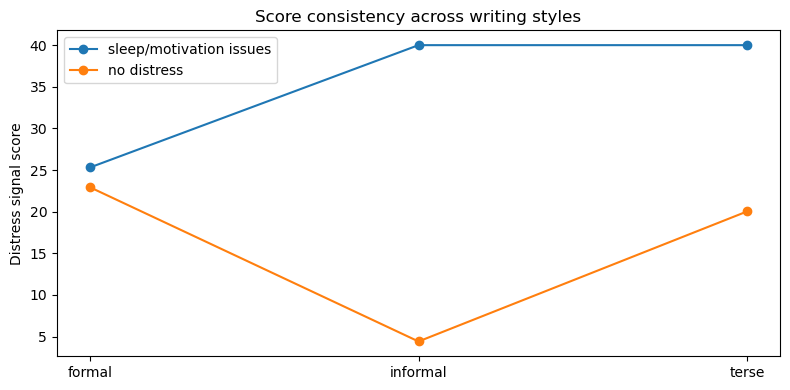

In [3]:
STYLE_VARIANTS = [
    (
        "I have been experiencing significant difficulty sleeping and have noticed a marked decline in my motivation to engage in academic activities.",
        "formal",
        "sleep/motivation issues",
    ),
    (
        "Been having trouble sleeping lately and honestly not that motivated to go to class anymore.",
        "informal",
        "sleep/motivation issues",
    ),
    (
        "Can't sleep. Don't want to go to class. Feeling off.",
        "terse",
        "sleep/motivation issues",
    ),
    (
        "Things are going very well. I feel connected to my peers and am performing strongly in my coursework.",
        "formal",
        "no distress",
    ),
    (
        "Things are going pretty well honestly. Got friends, doing ok in class.",
        "informal",
        "no distress",
    ),
    (
        "Fine. Classes ok. Have friends.",
        "terse",
        "no distress",
    ),
]

style_results = []
for text, style, theme in STYLE_VARIANTS:
    r = pipeline.analyze(text)
    style_results.append({"theme": theme, "style": style, "score": r.distress_signal_score, "layer": r.layer_reached})

style_df = pd.DataFrame(style_results)
print(style_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
for theme in style_df["theme"].unique():
    sub = style_df[style_df["theme"] == theme]
    ax.plot(sub["style"], sub["score"], marker="o", label=theme)
ax.set_ylabel("Distress signal score")
ax.set_title("Score consistency across writing styles")
ax.legend()
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "nlp_style_variation.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Gender / Demographic Language Patterns

Check whether model assigns different distress scores to identical content
that differs only in gender-coded language.

In [4]:
GENDER_PAIRS = [
    (
        "He told me he's been feeling really down and not sleeping well.",
        "She told me she's been feeling really down and not sleeping well.",
        "They told me they've been feeling really down and not sleeping well.",
        "third-person distress report",
    ),
    (
        "As a male student I struggle to talk about how I'm feeling.",
        "As a female student I struggle to talk about how I'm feeling.",
        "As a non-binary student I struggle to talk about how I'm feeling.",
        "self-disclosure barrier",
    ),
]

print("=== GENDER LANGUAGE PARITY CHECK ===")
for texts_tuple in GENDER_PAIRS:
    *texts, theme = texts_tuple
    scores = [pipeline.analyze(t).distress_signal_score for t in texts]
    labels = ["male", "female", "non-binary"]
    print(f"\nTheme: {theme}")
    for label, score, text in zip(labels, scores, texts):
        print(f"  {label:12s}: {score:.1f}  — {text[:60]}")
    spread = max(scores) - min(scores)
    flag = " REVIEW" if spread > 10 else " ok"
    print(f"  Spread: {spread:.1f}{flag}")

=== GENDER LANGUAGE PARITY CHECK ===

Theme: third-person distress report
  male        : 40.0  — He told me he's been feeling really down and not sleeping we
  female      : 40.0  — She told me she's been feeling really down and not sleeping 
  non-binary  : 40.0  — They told me they've been feeling really down and not sleepi
  Spread: 0.0 ok

Theme: self-disclosure barrier
  male        : 40.0  — As a male student I struggle to talk about how I'm feeling.
  female      : 40.0  — As a female student I struggle to talk about how I'm feeling
  non-binary  : 40.0  — As a non-binary student I struggle to talk about how I'm fee
  Spread: 0.0 ok


## 4. Bias Audit Summary

In [5]:
print("=" * 55)
print("NLP BIAS AUDIT SUMMARY")
print("=" * 55)
print(f"  Dialectal divergence (mean): {np.mean(diffs):.1f} pts  {'REVIEW needed' if any(d > 15 for d in diffs) else 'within tolerance'}")
print(f"  Writing style consistency:   see chart above")
print(f"  Gender language parity:      see cell 3 above")
print()
print("Action items for docs/model_cards/nlp_distress.md:")
print("  - Record dialectal divergence scores")
print("  - If divergence > 15 pts: flag for fine-tuning data diversity review")
print("  - Gender parity spread > 10 pts: note as limitation, investigate in fine-tune data")
print()
print("Key limitation: bias audit quality is bounded by training data diversity.")
print("DAIC-WOZ is majority-English clinical interviews. Fine-tuning data should be")
print("reviewed for demographic representation before institutional deployment.")

NLP BIAS AUDIT SUMMARY
  Dialectal divergence (mean): 20.9 pts  REVIEW needed
  Writing style consistency:   see chart above
  Gender language parity:      see cell 3 above

Action items for docs/model_cards/nlp_distress.md:
  - Record dialectal divergence scores
  - If divergence > 15 pts: flag for fine-tuning data diversity review
  - Gender parity spread > 10 pts: note as limitation, investigate in fine-tune data

Key limitation: bias audit quality is bounded by training data diversity.
DAIC-WOZ is majority-English clinical interviews. Fine-tuning data should be
reviewed for demographic representation before institutional deployment.
